# DS605 - Lab Assignment 4
This notebook cleans the NYC Airbnb data, trains a few regression models to predict nightly price, tunes the best one, and saves it so it can be used later in a Streamlit/Gradio app.

# Task 1 - Data Analysis and Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Reading the CSV and looking at the first few rows to see what columns.

In [ ]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Checking the size of the data, column types, missing values and duplicate rows in one go instead of separate cells for each.

In [ ]:
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (48895, 16)

Column types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Missing values:
reviews_per_month    10052
last_review          10052
host_name               21
name                    16
dtype: int64

Duplicate rows: 0


Only `name`, `host_name`, `last_review` and `reviews_per_month` have missing values. `name` and `host_name` are text fields we won't use for prediction, `last_review` is a date we also won't use, and a missing `reviews_per_month` simply means the listing has no reviews yet, so we can fill it with 0 later.

## A price of $0 doesn't make sense for a real listing, so those rows are dropped.

In [ ]:
print("Listings with price <= 0:", (df["price"] <= 0).sum())
df = df[df["price"] > 0].copy()
print("Shape after removing them:", df.shape)

Listings with price <= 0: 11
Shape after removing them: (48884, 16)


## Plotting the price as a histogram and a boxplot together. Both show the same thing: most prices are low, but a small number of very expensive listings stretch the scale out (a right-skewed distribution).

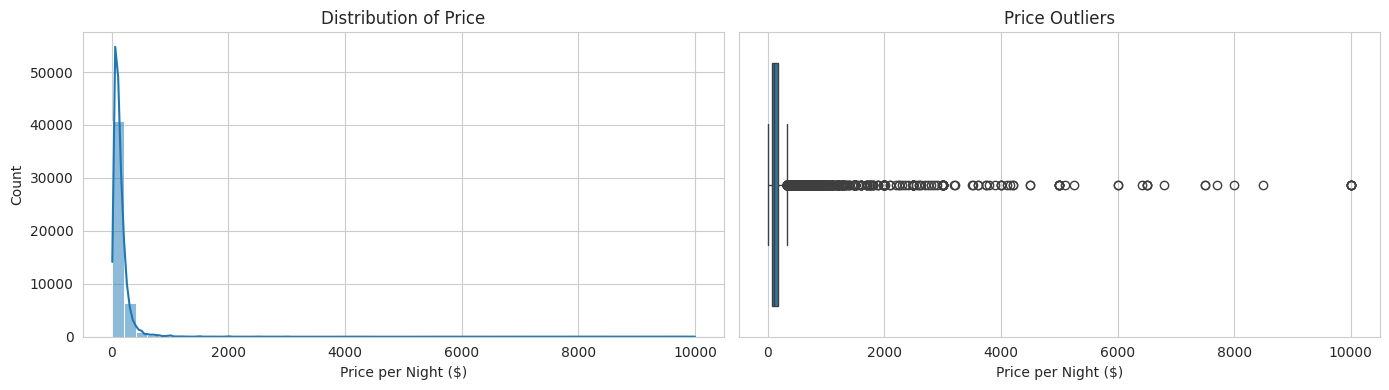

,price
0.900,269.0
0.950,355.0
0.990,799.0
0.995,1000.0
0.999,3000.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price per Night ($)")

sns.boxplot(x=df["price"], ax=axes[1])
axes[1].set_title("Price Outliers")
axes[1].set_xlabel("Price per Night ($)")

plt.tight_layout()
plt.show()

df["price"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

## Checking how many listings fall into each room type, and how price varies by room type and by neighbourhood group, all in one figure.

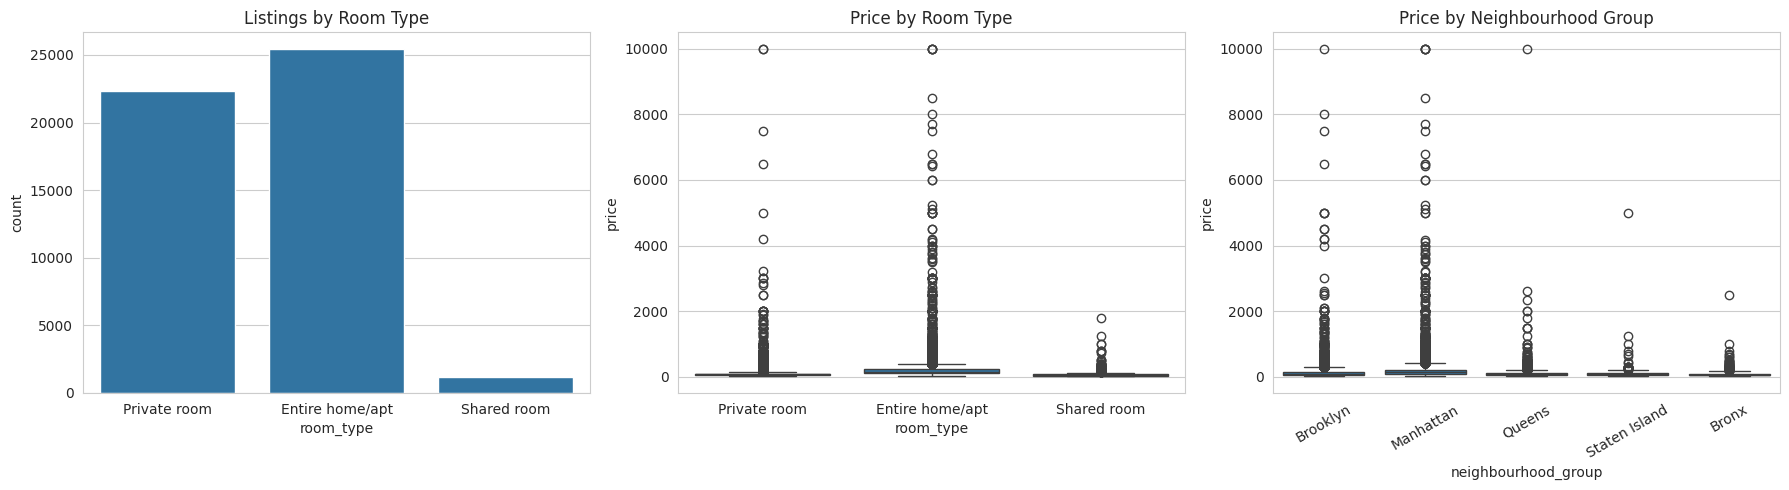

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="room_type", ax=axes[0])
axes[0].set_title("Listings by Room Type")

sns.boxplot(data=df, x="room_type", y="price", ax=axes[1])
axes[1].set_title("Price by Room Type")

sns.boxplot(data=df, x="neighbourhood_group", y="price", ax=axes[2])
axes[2].set_title("Price by Neighbourhood Group")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

An entire home costs more than a private or shared room, and Manhattan listings tend to be the most expensive. These two columns look useful for predicting price.

## A quick heatmap to see which numeric columns move together with price.

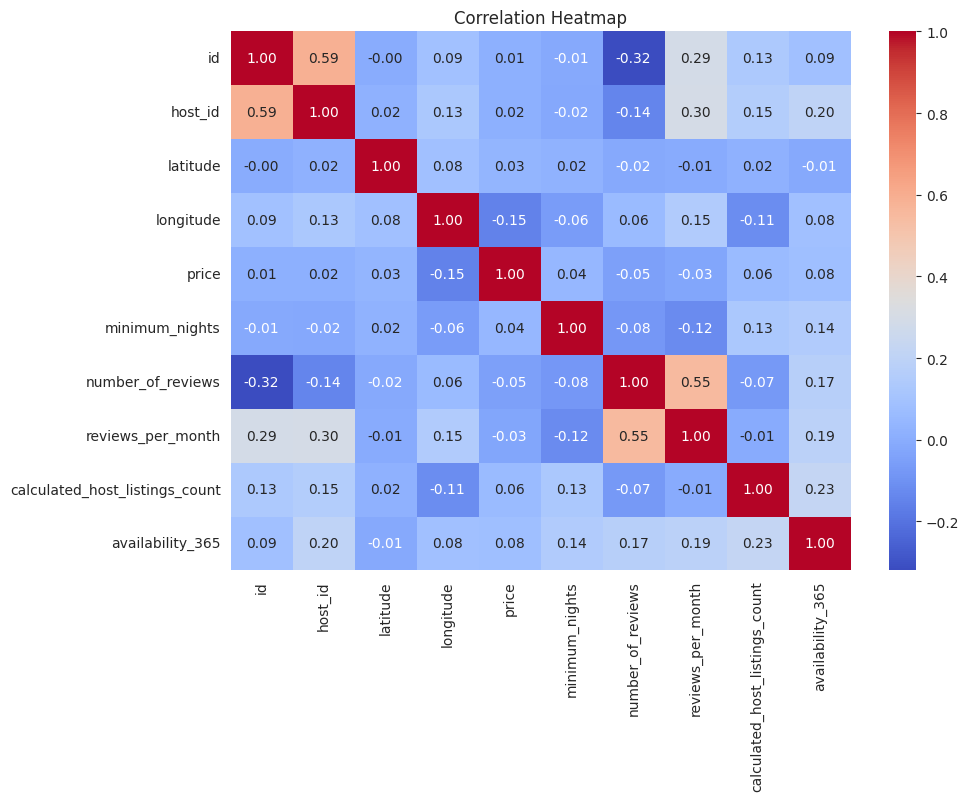

In [ ]:
numeric_columns = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_columns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

None of the numeric columns are strongly correlated with price on their own, which means the model will need the categorical columns (room type, location) as well.

## Drop columns we won't use`id` and `host_id` are just identifiers, and `name` / `host_name` are free text — none of these help predict price directly.

In [ ]:
df = df.drop(columns=["id", "host_id", "name", "host_name"])
df.columns.tolist()

['neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

## New feature: days since last reviewA raw date like `last_review` isn't something a model can use directly, but how *recently* a listing was reviewed can say a lot about how active or popular it is. We turn the date into a number: days between the most recent review in the whole dataset and each listing's last review. Listings with no reviews at all get a large value, since they haven't been reviewed in a very long time (or ever).

In [ ]:
df["last_review"] = pd.to_datetime(df["last_review"])
most_recent_date = df["last_review"].max()

df["days_since_last_review"] = (most_recent_date - df["last_review"]).dt.days

no_review_fill_value = int(df["days_since_last_review"].max()) + 1
df["days_since_last_review"] = df["days_since_last_review"].fillna(no_review_fill_value)

df = df.drop(columns=["last_review"])

print("Listings with no reviews filled with:", no_review_fill_value, "days")
df["days_since_last_review"].describe()

Listings with no reviews filled with: 3025 days


,days_since_last_review
count,48884.000000
mean,841.972609
std,1170.303591
min,0.000000
25%,19.000000
50%,186.000000
75%,1201.000000
max,3025.000000


## A missing `reviews_per_month` means no reviews yet, so 0 is the right value.

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df.isnull().sum().sum()

np.int64(0)

## Some listings ask for hundreds or even 1000+ minimum nights, which is not realistic for a short-term rental and would confuse the model. Capping this column at its 99th percentile keeps the extreme values from distorting things without throwing away rows.

In [ ]:
min_nights_cap = df["minimum_nights"].quantile(0.99)
df["minimum_nights"] = df["minimum_nights"].clip(upper=min_nights_cap)
print("Minimum nights capped at:", min_nights_cap)

Minimum nights capped at: 45.0


## The very top prices are rare and would pull the model off course, so listings above the 99th percentile are removed, matching what the boxplot showed earlier.

In [ ]:
price_limit = df["price"].quantile(0.99)
df = df[df["price"] <= price_limit].copy()
print("99th percentile price:", price_limit)
print("Shape after removing extreme prices:", df.shape)

99th percentile price: 799.0
Shape after removing extreme prices: (48410, 12)


## Since price is right-skewed (a few very high values), models usually do better predicting `log(price)` instead of the raw price. We don't need a separate column for this — it's applied automatically inside the model in Task 2 using `TransformedTargetRegressor`, and predictions are converted back to normal dollars automatically.

In [ ]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(20).index
df["neighbourhood"] = df["neighbourhood"].where(df["neighbourhood"].isin(top_neighbourhoods), "Other")
print("Neighbourhood categories now:", df["neighbourhood"].nunique())

Neighbourhood categories now: 21


## Split features and target

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type"]
numeric_columns = [c for c in X.columns if c not in categorical_columns]

print("Categorical columns:", categorical_columns)
print("Numeric columns:", numeric_columns)

Categorical columns: ['neighbourhood_group', 'neighbourhood', 'room_type']
Numeric columns: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']


## Splitting before encoding so the encoder only ever learns categories from the training data, which is a more realistic setup and avoids any leakage from the test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (38728, 11)
Testing data: (9682, 11)


# Task 2 - Model Training and Evaluation

## we use a `ColumnTransformer` inside a `Pipeline`. This does the encoding automatically, handles categories it hasn't seen before (like a brand-new neighbourhood typed into the app) without crashing, and can be saved as one single object.

In [ ]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import time

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [ ]:
def build_and_evaluate(model, name, preprocessor_to_use=None):
    if preprocessor_to_use is None:
        preprocessor_to_use = preprocessor

    pipeline = Pipeline([
        ("preprocess", preprocessor_to_use),
        ("model", model)
    ])

    wrapped_model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    start_time = time.time()
    wrapped_model.fit(X_train, y_train)
    train_time = time.time() - start_time

    train_pred = wrapped_model.predict(X_train)
    test_pred = wrapped_model.predict(X_test)

    metrics = {
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train Time (s)": round(train_time, 2)
    }

    print(f"{name} done in {train_time:.2f}s | Test RMSE: {metrics['Test RMSE']:.2f} "
          f"| Test R2: {metrics['Test R2']:.4f} "
          f"| Overfit gap (Train R2 - Test R2): {metrics['Train R2'] - metrics['Test R2']:.4f}")

    return wrapped_model, metrics

## Train both modelsRandom Forest and Gradient Boosting are both good baseline choices for this kind of tabular data.

In [ ]:
rf_model, rf_metrics = build_and_evaluate(
    RandomForestRegressor(
        n_estimators=150, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    "Random Forest"
)

gb_model, gb_metrics = build_and_evaluate(
    GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=5,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42
    ),
    "Gradient Boosting"
)

Random Forest done in 125.62s | Test RMSE: 72.57 | Test R2: 0.5161 | Overfit gap (Train R2 - Test R2): 0.2630
Gradient Boosting done in 24.22s | Test RMSE: 75.61 | Test R2: 0.4747 | Overfit gap (Train R2 - Test R2): 0.0067


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor

poly_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num_poly", PolynomialFeatures(degree=2, include_bias=False), numeric_columns)
    ],
    remainder="passthrough"
)

In [ ]:
lr_model, lr_metrics = build_and_evaluate(
    LinearRegression(),
    "Linear Regression"
)

poly_model, poly_metrics = build_and_evaluate(
    LinearRegression(),
    "Polynomial Regression (degree 2)",
    preprocessor_to_use=poly_preprocessor
)

xgb_model, xgb_metrics = build_and_evaluate(
    XGBRegressor(
        n_estimators=200, learning_rate=0.08, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        random_state=42, n_jobs=-1
    ),
    "XGBoost"
)

Linear Regression done in 0.23s | Test RMSE: 80.66 | Test R2: 0.4021 | Overfit gap (Train R2 - Test R2): -0.0170
Polynomial Regression (degree 2) done in 0.21s | Test RMSE: 79.55 | Test R2: 0.4185 | Overfit gap (Train R2 - Test R2): -0.0191
XGBoost done in 1.39s | Test RMSE: 73.26 | Test R2: 0.5069 | Overfit gap (Train R2 - Test R2): 0.0472


In [ ]:
results = pd.DataFrame([rf_metrics, gb_metrics, xgb_metrics, lr_metrics, poly_metrics])
results

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Time (s)
0,Random Forest,24.495236,41.907632,48.715918,72.568925,0.779064,0.516056,125.62
1,Gradient Boosting,41.950903,43.051631,74.639412,75.608276,0.481367,0.474669,24.22
2,XGBoost,38.668007,42.002575,69.208330,73.255496,0.554097,0.506855,1.39
3,Linear Regression,46.480776,46.568406,81.275131,80.662906,0.385051,0.402082,0.23
4,Polynomial Regression (degree 2),45.716280,45.680961,80.320384,79.549768,0.399414,0.418470,0.21


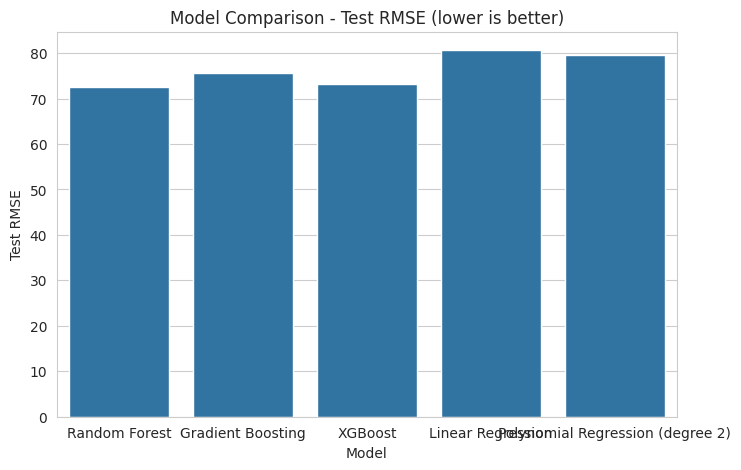

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Test RMSE")
plt.title("Model Comparison - Test RMSE (lower is better)")
plt.show()

## Hyperparameter tuning`RandomizedSearchCV` tries a handful of random combinations from each parameter grid and keeps the best one. It's set to use only 2 cross-validation folds and 4 random combinations per model here — enough to find good settings without testing dozens of combinations — and it automatically refits the winning combination on the full training set at the end, so no accuracy is lost from using less data. Because the pipeline step is named `model`, its parameters are referenced with the `regressor__model__` prefix.Gradient Boosting also gets a `subsample` option here (each tree only looks at part of the data), which usually makes it generalize a little better and is a common reason it slightly outperforms Random Forest on this kind of dataset.

In [ ]:
def tune_model(model, param_grid, name):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    wrapped_model = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    search = RandomizedSearchCV(
        estimator=wrapped_model,
        param_distributions={f"regressor__model__{k}": v for k, v in param_grid.items()},
        n_iter=4,
        cv=2,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()
    search.fit(X_train, y_train)   # refits the best combination on all of X_train automatically
    print(f"{name} tuning done in {time.time() - start_time:.2f}s")
    print("Best params:", search.best_params_)

    return search.best_estimator_

In [ ]:
rf_tuned = tune_model(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        "n_estimators": [100, 150],
        "max_depth": [10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest"
)

gb_tuned = tune_model(
    GradientBoostingRegressor(random_state=42),
    {
        "n_estimators": [150, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 4, 5],
        "subsample": [0.7, 0.85, 1.0],
        "min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting"
)

xgb_tuned = tune_model(
    XGBRegressor(random_state=42, n_jobs=-1),
    {
        "n_estimators": [150, 200, 300],
        "learning_rate": [0.05, 0.08, 0.1],
        "max_depth": [4, 6, 8],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    },
    "XGBoost"
)

Random Forest tuning done in 416.95s
Best params: {'regressor__model__n_estimators': 150, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 1, 'regressor__model__max_depth': 15}
Gradient Boosting tuning done in 69.05s
Best params: {'regressor__model__subsample': 1.0, 'regressor__model__n_estimators': 200, 'regressor__model__min_samples_leaf': 1, 'regressor__model__max_depth': 4, 'regressor__model__learning_rate': 0.1}
XGBoost tuning done in 9.19s
Best params: {'regressor__model__subsample': 0.7, 'regressor__model__n_estimators': 300, 'regressor__model__max_depth': 8, 'regressor__model__learning_rate': 0.05, 'regressor__model__colsample_bytree': 0.7}


## Whichever tuned model has the lower test RMSE becomes the final model.

In [ ]:
candidates = {
    "Random Forest": rf_tuned,
    "Gradient Boosting": gb_tuned,
    "XGBoost": xgb_tuned
}

final_scores = {}
for name, model in candidates.items():
    pred = model.predict(X_test)
    final_scores[name] = {
        "model": model,
        "predictions": pred,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    }

final_model_name = min(final_scores, key=lambda n: final_scores[n]["RMSE"])
final_model = final_scores[final_model_name]["model"]
final_predictions = final_scores[final_model_name]["predictions"]

print("Final Model:", final_model_name)
print("Test MAE :", round(final_scores[final_model_name]["MAE"], 2))
print("Test RMSE:", round(final_scores[final_model_name]["RMSE"], 2))
print("Test R2  :", round(final_scores[final_model_name]["R2"], 4))

Final Model: XGBoost
Test MAE : 41.75
Test RMSE: 72.7
Test R2  : 0.5143


## Points close to the dashed line mean the prediction was close to the real price.

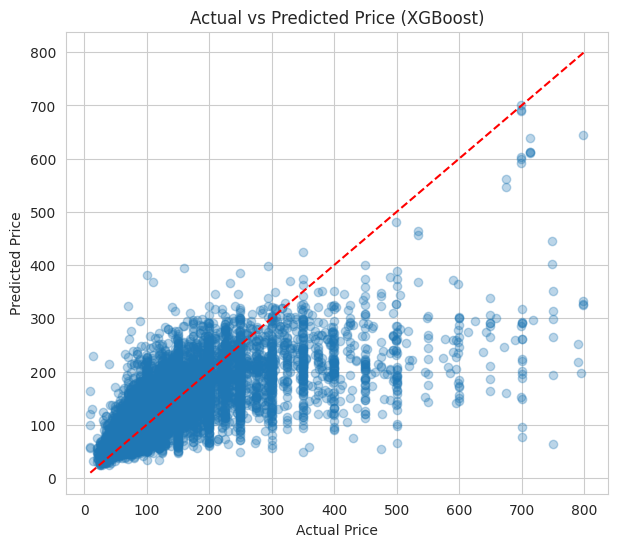

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--", color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price ({final_model_name})")
plt.show()

## Pulling the feature names out of the pipeline's encoder so the importance chart shows readable labels instead of raw column numbers.

In [ ]:
feature_names = final_model.regressor_.named_steps["preprocess"].get_feature_names_out()
importances = final_model.regressor_.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
26,cat__room_type_Entire home/apt,0.419098
27,cat__room_type_Private room,0.140020
2,cat__neighbourhood_group_Manhattan,0.079733
28,cat__room_type_Shared room,0.057368
19,cat__neighbourhood_Midtown,0.045312
3,cat__neighbourhood_group_Queens,0.025191
25,cat__neighbourhood_Williamsburg,0.019478
30,remainder__longitude,0.013075
29,remainder__latitude,0.012465
23,cat__neighbourhood_Washington Heights,0.012398


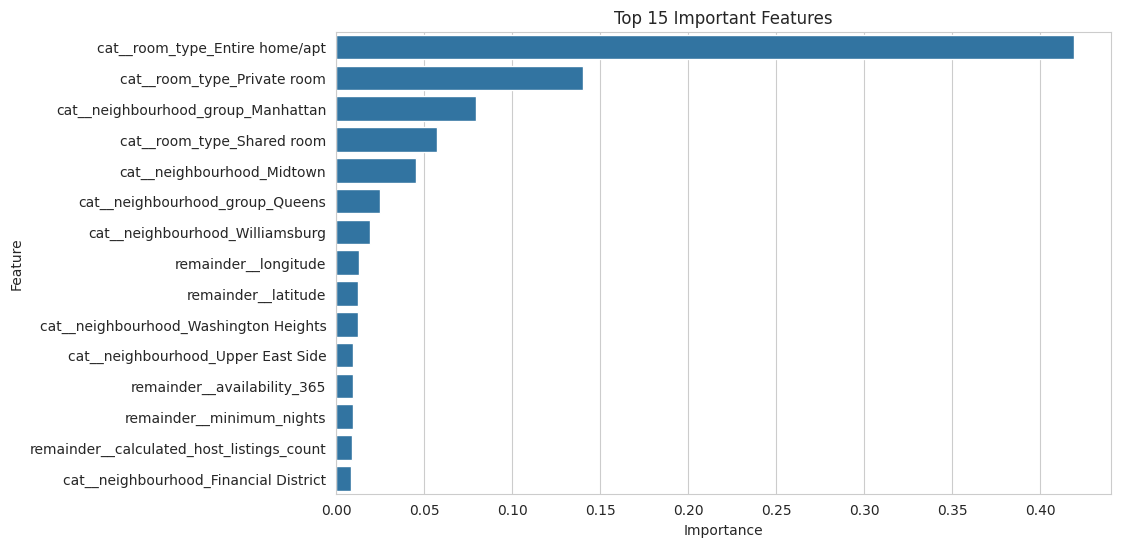

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features")
plt.show()

In [ ]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(final_model, "model/airbnb_price_model.pkl")

metadata = {
    "neighbourhood_groups": sorted(df["neighbourhood_group"].unique().tolist()),
    "neighbourhoods": sorted(df["neighbourhood"].unique().tolist()),
    "room_types": sorted(df["room_type"].unique().tolist()),
    "price_limit": float(price_limit),
    "min_nights_cap": float(min_nights_cap),
    "no_review_fill_value": no_review_fill_value
}
joblib.dump(metadata, "model/model_metadata.pkl")

print("Model and metadata saved successfully.")

Model and metadata saved successfully.


## Since the pipeline handles encoding on its own, predicting on a new listing is just a normal `.predict()` call on a plain DataFrame

In [ ]:
sample = pd.DataFrame({
    "neighbourhood_group": ["Manhattan"],
    "neighbourhood": ["Midtown"],
    "latitude": [40.75362],
    "longitude": [-73.98377],
    "room_type": ["Entire home/apt"],
    "minimum_nights": [2],
    "number_of_reviews": [50],
    "reviews_per_month": [1.5],
    "calculated_host_listings_count": [2],
    "availability_365": [200],
    "days_since_last_review": [15]
})

predicted_price = final_model.predict(sample)[0]
print("Predicted Airbnb nightly price: $", round(predicted_price, 2))

Predicted Airbnb nightly price: $ 245.81
